__No masking (except for the target mask)__

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
          'axes.labelsize': 'large',
          'axes.titlesize': 'large',
          'xtick.labelsize': 'large',
          'ytick.labelsize': 'large',
          'figure.facecolor': 'w',
          'xtick.top': True,
          'ytick.right': True,
          'xtick.direction': 'in',
          'ytick.direction': 'in',
         }
plt.rcParams.update(params)

In [3]:
# perexp = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_perexp_lrg.fits'))
perexp = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_perexp_lrg.fits'))
perexp['EFFTIME_ELG'] = 8.60 * perexp['TSNR2_ELG']
perexp['EFFTIME_LRG'] = 12.15 * perexp['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = perexp['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove "no data" fibers
mask = perexp['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# # Apply LRG mask
# mask = perexp['lrg_mask']==0
# print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# perexp = perexp[mask]

# Remove QSO targets
mask = perexp['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove objects classified as QSOs
mask = perexp['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove objects classified as STARs
mask = perexp['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = perexp['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# perexp = perexp[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(perexp['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# perexp = perexp[~mask_bad]
# print(len(perexp), len(np.unique(perexp['TARGETID'])))

# Redshift quality cut
perexp['q'] = perexp['ZWARN']==0
perexp['q'] &= (perexp['Z']<1.5)
perexp['q'] &= perexp['DELTACHI2']>15

FIBERSTATUS 464751 107007 0.18715435551404616
No data 464751 0 0.0
Remove QSO targets 447964 16787 0.036120417169624164
Remove objects classified as QSOs: 441827 6137 0.013699761587984749
Remove objects classified as STARs: 435185 6642 0.015033033291310852


In [4]:
# cat_1x = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_1x_depth_lrg.fits'))
cat_1x = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_1x_depth_lrg.fits'))
cat_1x['EFFTIME_ELG'] = 8.60 * cat_1x['TSNR2_ELG']
cat_1x['EFFTIME_LRG'] = 12.15 * cat_1x['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat_1x['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove "no data" fibers
mask = cat_1x['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# # Apply LRG mask
# mask = cat_1x['lrg_mask']==0
# print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat_1x = cat_1x[mask]

# Remove QSO targets
mask = cat_1x['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove objects classified as QSOs
mask = cat_1x['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove objects classified as STARs
mask = cat_1x['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat_1x['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat_1x = cat_1x[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat_1x['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat_1x = cat_1x[~mask_bad]
# print(len(cat_1x), len(np.unique(cat_1x['TARGETID'])))

# Redshift quality cut
cat_1x['q'] = cat_1x['ZWARN']==0
cat_1x['q'] &= (cat_1x['Z']<1.5)
cat_1x['q'] &= cat_1x['DELTACHI2']>15

FIBERSTATUS 27110 4943 0.15421333416528873
No data 27110 0 0.0
Remove QSO targets 26513 597 0.022021394319439322
Remove objects classified as QSOs: 26177 336 0.012673028325727002
Remove objects classified as STARs: 25820 357 0.013637926423959964


In [5]:
cat = vstack([perexp, cat_1x], join_type='inner')
print(len(cat))

461005


In [6]:
# deep = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_cumulative_lrg.fits'))
deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))
deep['EFFTIME_ELG'] = 8.60 * deep['TSNR2_ELG']
deep['EFFTIME_LRG'] = 12.15 * deep['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# # Apply LRG mask
# mask = deep['lrg_mask']==0
# print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# deep = deep[mask]

# # Remove QSO targets
# mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
# print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# deep = deep[mask]

# Remove objects classified as QSOs
mask = deep['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove objects classified as STARs
mask = deep['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(deep['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# deep = deep[~mask_bad]
# print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
deep.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(deep['TARGETID'], return_index=True)
deep = deep[idx_keep]
print(len(deep), len(np.unique(deep['TARGETID'])))

#####################################################################################################################
deep_tmp = deep.copy()
# Require a minimum depth
min_depth = 3000.
mask = deep_tmp['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep_tmp = deep_tmp[mask]

deep_columns_old = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'DELTACHI2', 'EFFTIME_LRG', 'EFFTIME_ELG']
deep_columns_new = ['TARGETID', 'Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'DELTACHI2_deep', 'EFFTIME_LRG_deep', 'EFFTIME_ELG_deep']
deep_tmp.rename_columns(deep_columns_old, deep_columns_new)

cat = join(cat, deep_tmp[deep_columns_new], keys='TARGETID', join_type='inner')
print(len(cat))
#####################################################################################################################

# Redshift quality cut
deep['q'] = deep['ZWARN']==0
deep['q'] &= (deep['Z']<1.5)
deep['q'] &= deep['DELTACHI2']>15

COADD_FIBERSTATUS 46319 8916 0.16141938987960533
No data 45437 882 0.01904186187093849
Remove objects classified as QSOs: 44067 1370 0.030151638532473535
Remove objects classified as STARs: 43076 991 0.02248848344566229
42926 42926
Min depth 33183 9743 0.7730280016773051
403933


In [7]:
# main = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_lrg.fits'))
main = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/main_cumulative_lrg.fits'))
main['EFFTIME_ELG'] = 8.60 * main['TSNR2_ELG']
main['EFFTIME_LRG'] = 12.15 * main['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = main['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove "no data" fibers
mask = main['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# # Apply LRG mask
# mask = main['lrg_mask']==0
# print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# main = main[mask]

# Remove QSO targets
mask = main['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove objects classified as QSOs
mask = main['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove objects classified as STARs
mask = main['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = main['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# main = main[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(main['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# main = main[~mask_bad]
# print(len(main), len(np.unique(main['TARGETID'])))

# Redshift quality cut
main['q'] = main['ZWARN']==0
main['q'] &= (main['Z']<1.5)
main['q'] &= main['DELTACHI2']>15

# Add Main LRGs from SV
main['main_survey'] = True
cat['main_survey'] = False
mask = (cat['main_lrg'])
# mask &= (cat['EFFTIME_LRG']>800) & (cat['EFFTIME_LRG']<1200)
main = vstack([main, cat[mask]], join_type='inner')
print(len(main))

FIBERSTATUS 338266 7165 0.020742203218587794
No data 338265 1 2.9562533627382e-06
Remove QSO targets 332797 5468 0.016164841174818558
Remove objects classified as QSOs: 328812 3985 0.011974266594951277
Remove objects classified as STARs: 323948 4864 0.014792647470286973
437556


---------

In [8]:
# Catastrophic redshift failures
zdiff_threshold = 0.0033
mask_fail = np.abs((cat['Z'] - cat['Z_deep'])/(1 + cat['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also reject objects with ZWARN!=0 or z>1.5
mask_deep = (cat['ZWARN_deep']==0) & (cat['Z_deep']<1.5)
mask_deep_fail = ~mask_deep
# mask_deep = (cat['ZWARN_deep']==0) & (cat['Z_deep']<1.5) & (cat['DELTACHI2_deep']>30)
mask_fail |= mask_deep_fail
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
print()

print('Main LRGs in SV:')
mask = cat['main_lrg'].copy()
print('Catastrophic failure rate (all): {:.1f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))
mask &= (cat['EFFTIME_LRG']>800) & (cat['EFFTIME_LRG']<1200)
print('Catastrophic failure rate (800s<EFFTIME<1200s): {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))

74373 0.18412211926235292
74740 0.185030685782048

Main LRGs in SV:
Catastrophic failure rate (all): 10.5% (11926/113608)
Catastrophic failure rate (800s<EFFTIME<1200s): 0.74% (123/16586)


In [9]:
print('Quality cuts\n')
print(np.sum(~cat['q']), np.sum(~cat['q'])/len(cat))
mask = (cat['EFFTIME_LRG']>800) & (cat['EFFTIME_LRG']<1200)
# Failures in "good redshifts"
print(np.sum(mask_fail & cat['q'] & mask), np.sum(mask_fail & cat['q'] & mask)/np.sum(cat['q'] & mask))
print()

print('Main LRGs in SV:')
mask = cat['main_lrg'].copy()
print('Rejection rate (all): {:.1f}% ({}/{})'.format(100*np.sum((~cat['q']) & mask)/np.sum(mask), np.sum((~cat['q']) & mask), np.sum(mask)))
mask &= (cat['EFFTIME_LRG']>800) & (cat['EFFTIME_LRG']<1200)
print('Rejection rate (800s<EFFTIME<1200s): {:.2f}% ({}/{})'.format(100*np.sum((~cat['q']) & mask)/np.sum(mask), np.sum((~cat['q']) & mask), np.sum(mask)))
print('Catastrophic failure rate in accepted redshifts (800s<EFFTIME<1200s): {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & cat['q'] & mask)/np.sum(cat['q'] & mask), np.sum(mask_fail & cat['q'] & mask), np.sum(cat['q'] & mask)))
print('Catastrophic failure rate in rejected redshifts (800s<EFFTIME<1200s): {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & (~cat['q']) & mask)/np.sum((~cat['q']) & mask), np.sum(mask_fail & (~cat['q']) & mask), np.sum((~cat['q']) & mask)))

Quality cuts

122337 0.30286458397803595
189 0.0034473324213406295

Main LRGs in SV:
Rejection rate (all): 17.9% (20331/113608)
Rejection rate (800s<EFFTIME<1200s): 1.29% (214/16586)
Catastrophic failure rate in accepted redshifts (800s<EFFTIME<1200s): 0.19% (31/16372)
Catastrophic failure rate in rejected redshifts (800s<EFFTIME<1200s): 42.99% (92/214)


In [10]:
print('Main LRGs in SV and Main Survey:')
mask = main['EFFTIME_LRG']>800
print('Rejection rate (EFFTIME>800s): {:.2f}% ({}/{})'.format(100*np.sum((~main['q']) & mask)/np.sum(mask), np.sum((~main['q']) & mask), np.sum(mask)))
mask_z = (main['Z']>0.4) & (main['Z']<1.1)
print('\"Target redshift efficiency\" (EFFTIME>800s): {:.2f}% ({}/{})'.format(100*np.sum((main['q'] & mask_z) & mask)/np.sum(mask), np.sum((main['q'] & mask_z) & mask), np.sum(mask)))

Main LRGs in SV and Main Survey:
Rejection rate (EFFTIME>800s): 1.17% (3875/331321)
"Target redshift efficiency" (EFFTIME>800s): 89.23% (295624/331321)


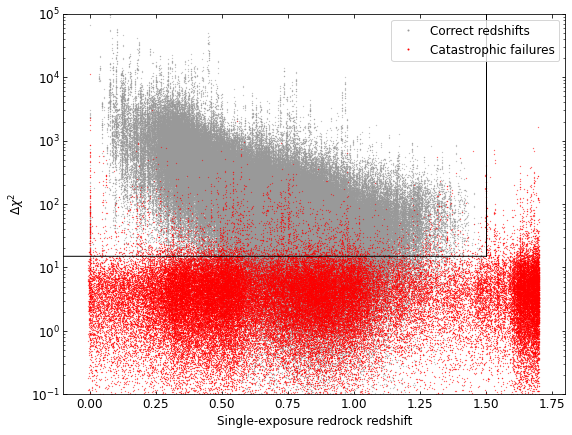

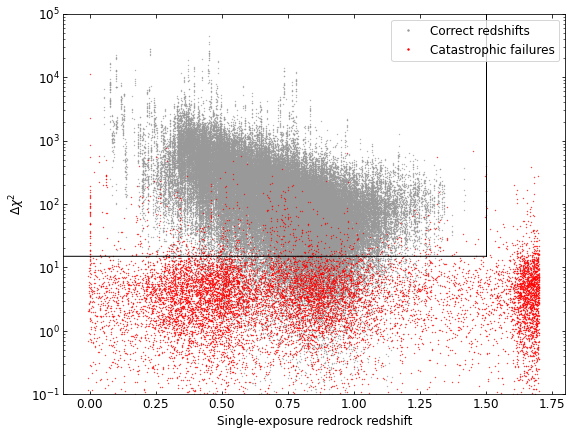

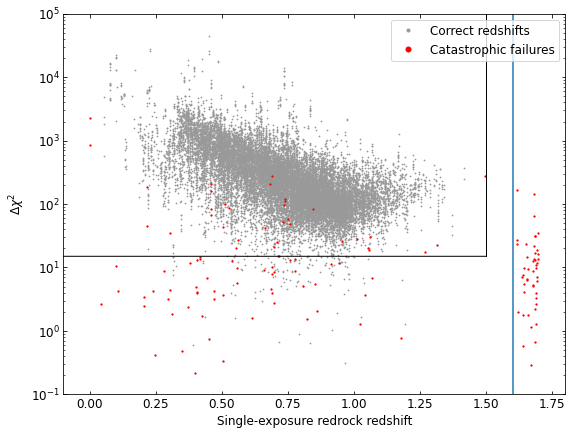

In [11]:
x = np.linspace(-1, 1.5, 10000)
y = np.ones_like(x) * 15.
y1 = np.linspace(15, 1e6)
x1 = np.ones_like(y1) * 1.5

mask = np.full(len(cat), True)
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=0.5, alpha=1, label='Correct redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=0.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
plt.show()

mask = cat['main_lrg'].copy()
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=0.7, alpha=1, label='Correct redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=0.7, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
plt.show()

mask = cat['main_lrg'].copy()
mask &= cat['EFFTIME_LRG']>800
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1.5, alpha=1, label='Correct redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=2.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.axvline(1.6)
plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
plt.show()

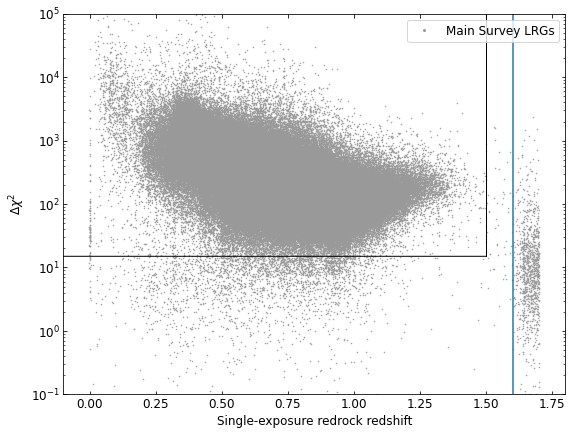

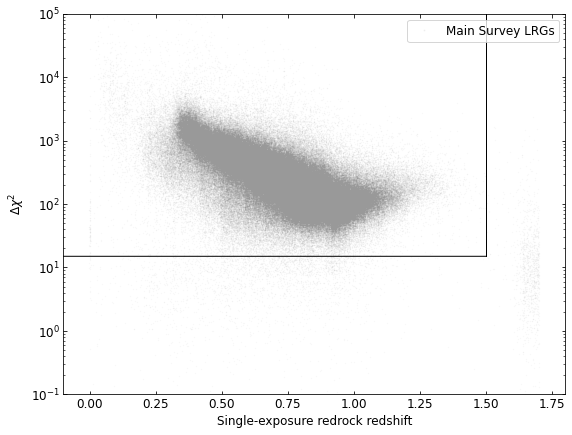

In [12]:
mask = main['EFFTIME_LRG']>800
plt.figure(figsize=(9, 7))
plt.plot(main['Z'][mask], main['DELTACHI2'][mask], '.', color='0.6', ms=1., alpha=1., label='Main Survey LRGs', zorder=1)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.axvline(1.6)
# plt.grid(alpha=0.5)
plt.show()

mask = main['EFFTIME_LRG']>800
plt.figure(figsize=(9, 7))
plt.plot(main['Z'][mask], main['DELTACHI2'][mask], '.', color='0.6', ms=0.5, alpha=.1, label='Main Survey LRGs', zorder=1)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
plt.show()

<ipython-input-13-cd5a732a5839>:16: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.axes().xaxis.set_minor_locator(AutoMinorLocator())


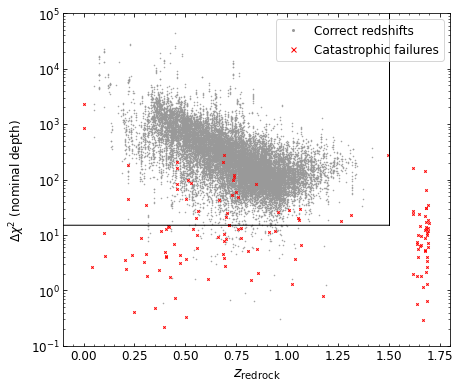

<ipython-input-13-cd5a732a5839>:35: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.axes().xaxis.set_minor_locator(AutoMinorLocator())


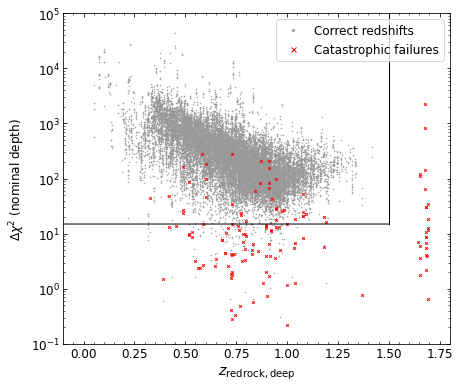

In [13]:
mask = cat['main_lrg'].copy()
mask &= cat['EFFTIME_LRG']>800
plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Correct redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('$z_\mathrm{redrock}$', fontsize='x-large')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=1, loc='upper right')
plt.axes().xaxis.set_minor_locator(AutoMinorLocator())
# plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z.pdf', dpi=150)
plt.show()

plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['Z_deep'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['Z_deep'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Correct redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('$z_\mathrm{redrock,deep}$', fontsize='x-large')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=1, loc='upper right')
plt.axes().xaxis.set_minor_locator(AutoMinorLocator())
# plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z_deep.pdf', dpi=150)
plt.show()

In [14]:
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
main['zfibermag'] = 22.5 - 2.5*np.log10(main['FIBERFLUX_Z']) - 1.211 * main['EBV']
deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']) - 1.211 * deep['EBV']

In [15]:
# mask = (cat['EFFTIME_LRG']>800) & (cat['zfibermag']<21.8)
# mask1 = mask & (cat['main_lrg'])
# mask2 = mask & (~cat['main_lrg'])
# plt.figure(figsize=(6.5, 5.5))
# plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Correct redshifts', zorder=1, rasterized=True)
# plt.plot(cat['Z'][mask1 & mask_fail], cat['DELTACHI2'][mask1 & mask_fail], 'rx', ms=3., alpha=1, label='Catastrophic failures', zorder=3, rasterized=True)
# plt.plot(cat['Z'][mask2 & mask_fail], cat['DELTACHI2'][mask2 & mask_fail], '.', color='darkorange', ms=1., alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
# plt.plot(x, y, color='k', lw=1)
# plt.plot(x1, y1, color='k', lw=1)
# # plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
# plt.yscale('log')
# plt.xlabel('Single-exposure redrock redshift')
# plt.ylabel('$\Delta \chi^2$')
# plt.axis([-0.1, 1.8, .1, 100000])
# plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
# plt.tight_layout()
# # plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z-1.pdf', dpi=200)
# plt.show()

# plt.figure(figsize=(6.5, 5.5))
# plt.plot(cat['Z_deep'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Correct redshifts', zorder=1, rasterized=True)
# plt.plot(cat['Z_deep'][mask1 & mask_fail], cat['DELTACHI2'][mask1 & mask_fail], 'rx', ms=3., alpha=1, label='Catastrophic failures', zorder=3, rasterized=True)
# plt.plot(cat['Z_deep'][mask2 & mask_fail], cat['DELTACHI2'][mask2 & mask_fail], '.', color='darkorange', ms=1., alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
# plt.plot(x, y, color='k', lw=1)
# plt.plot(x1, y1, color='k', lw=1)
# # plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
# plt.yscale('log')
# plt.xlabel('Deep redrock redshift')
# plt.ylabel('$\Delta \chi^2$')
# plt.axis([-0.1, 1.8, .1, 100000])
# plt.legend(markerscale=1, loc='upper right')
# plt.grid(alpha=0.5)
# plt.tight_layout()
# # plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z_deep-1.pdf', dpi=150)
# plt.show()

<ipython-input-16-293aef828749>:12: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.axes().xaxis.set_minor_locator(AutoMinorLocator())


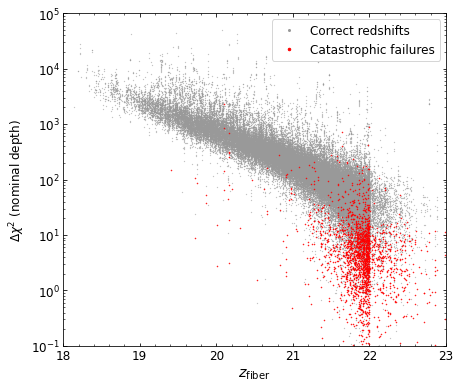

<ipython-input-16-293aef828749>:29: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.axes().xaxis.set_minor_locator(AutoMinorLocator())


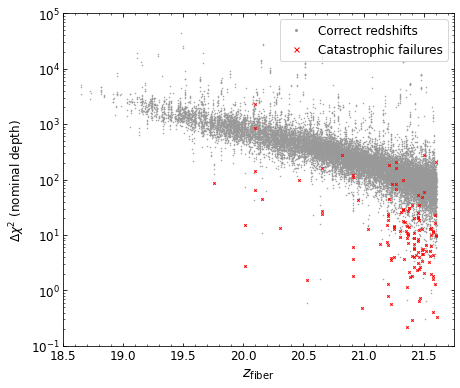

In [16]:
mask = cat['EFFTIME_LRG']>800
plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['zfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=0.5, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['zfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=1., alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Correct redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'r.', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.yscale('log')
plt.xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([18., 23., .1, 100000])
plt.legend(markerscale=1, loc='upper right')
plt.axes().xaxis.set_minor_locator(AutoMinorLocator())
# plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

mask = cat['main_lrg'].copy()
mask &= cat['EFFTIME_LRG']>800
plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['zfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['zfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Correct redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.yscale('log')
plt.xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([18.5, 21.75, .1, 100000])
plt.legend(markerscale=1, loc='upper right')
plt.axes().xaxis.set_minor_locator(AutoMinorLocator())
# plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_zfiber.pdf', dpi=150)
plt.show()

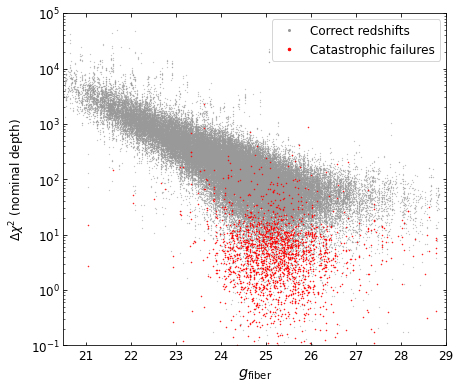

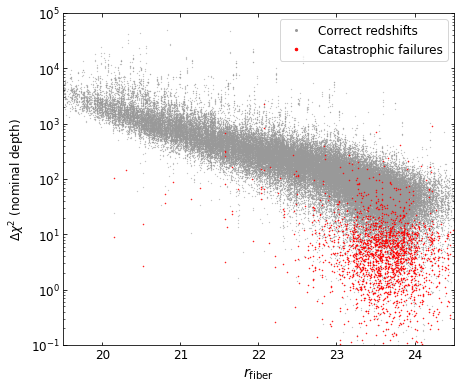

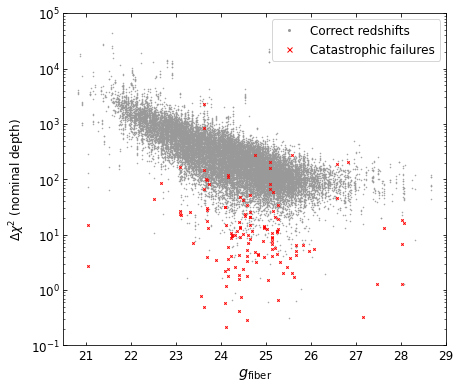

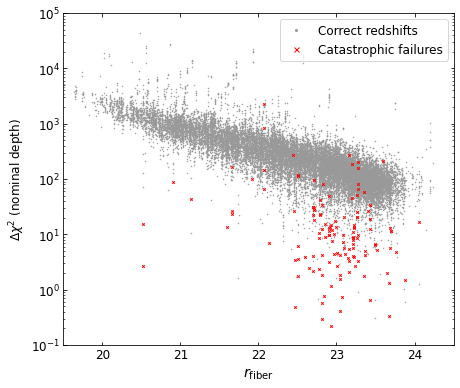

In [17]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_G']) - 3.214 * cat['EBV']
    main['gfibermag'] = 22.5 - 2.5*np.log10(main['FIBERFLUX_G']) - 3.214 * main['EBV']
    deep['gfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_G']) - 3.214 * deep['EBV']
    cat['rfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']) - 2.165 * cat['EBV']
    main['rfibermag'] = 22.5 - 2.5*np.log10(main['FIBERFLUX_R']) - 2.165 * main['EBV']
    deep['rfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_R']) - 2.165 * deep['EBV']

mask = cat['EFFTIME_LRG']>800

plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['gfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=0.5, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['gfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=1., alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Correct redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'r.', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.yscale('log')
plt.xlabel('$g_\mathrm{fiber}$', fontsize='x-large')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([20.5, 29., .1, 100000])
plt.legend(markerscale=1, loc='upper right')
# plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['rfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=0.5, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['rfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=1., alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Correct redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'r.', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.yscale('log')
plt.xlabel('$r_\mathrm{fiber}$', fontsize='x-large')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([19.5, 24.5, .1, 100000])
plt.legend(markerscale=1, loc='upper right')
# plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

mask &= cat['main_lrg'].copy()

plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['gfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['gfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Correct redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.yscale('log')
plt.xlabel('$g_\mathrm{fiber}$', fontsize='x-large')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([20.5, 29., .1, 100000])
plt.legend(markerscale=1, loc='upper right')
# plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['rfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['rfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Correct redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.yscale('log')
plt.xlabel('$r_\mathrm{fiber}$', fontsize='x-large')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([19.5, 24.5, .1, 100000])
plt.legend(markerscale=1, loc='upper right')
# plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
def binned_frac(x, y, bin_edges, minsize=10, error_floor=True):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p = np.sum(mask), np.mean(y[mask])
            if error_floor:
                p1 = np.maximum(p, 1/n)  # error floor
            else:
                p1 = p
            bin_frac[index] = p
            bin_frac_err[index] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    
    return bin_center, bin_frac, bin_frac_err

In [19]:
def failure_rate(flux, efftime, a0, a1, a2):
    sn = flux * np.sqrt(efftime)
    return np.clip(np.exp(a0*sn+a1)+a2/flux, 0, 1)

coeffs = [-0.0911, 3.34, 0.0228]

cat['FIBERFLUX_Z_EC'] = cat['FIBERFLUX_Z']*10**(0.4*1.211*cat['EBV'])
cat['fail_prob'] = failure_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)
main['FIBERFLUX_Z_EC'] = main['FIBERFLUX_Z']*10**(0.4*1.211*main['EBV'])
main['fail_prob'] = failure_rate(main['FIBERFLUX_Z_EC'], main['EFFTIME_LRG'], *coeffs)

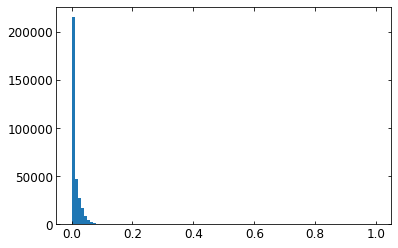

In [20]:
plt.hist(main['fail_prob'][main['main_survey']], 100);

## Failures rates vs EFFTIME

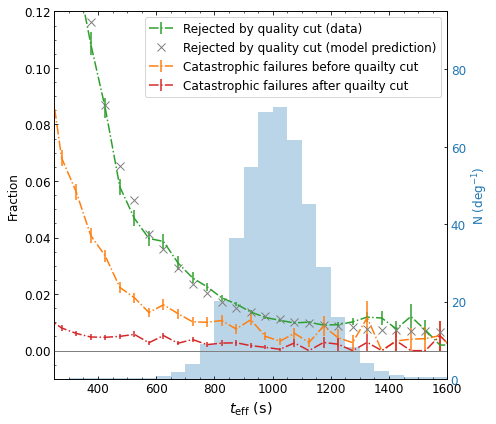

In [21]:
mask = cat['main_lrg'].copy()
bin_edges = np.linspace(0, 2000, 41)
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], mask_fail[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_still_fail_rate, bin_still_fail_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], (cat['q'] & mask_fail)[mask], bin_edges, minsize=10, error_floor=False)
bin_center_main, bin_reject_rate_main, bin_reject_rate_err_main = binned_frac(main['EFFTIME_LRG'], (~main['q']), bin_edges, minsize=10, error_floor=False)
_, bin_reject_rate_predict, _ = binned_frac(main['EFFTIME_LRG'], main['fail_prob'], bin_edges, minsize=10, error_floor=False)

fig, ax = plt.subplots(figsize=(7., 6.))
ax1 = ax
ax1.plot(bin_center, bin_reject_rate_predict, 'x', color='C7', ms=8,
             label='Rejected by quality cut (model prediction)')
ax1.errorbar(bin_center_main, bin_reject_rate_main,
             yerr=(np.clip(bin_reject_rate_err_main, None, bin_reject_rate_main), bin_reject_rate_err_main),
             fmt='-.', label='Rejected by quality cut (data)', color='C2')
ax1.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='-.', label='Catastrophic failures before quality cut')
ax1.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='-.', label='Catastrophic failures after quality cut')
ax2 = ax1.twinx()
ax2_color = 'C0'
area = len(main)/600
ax2.hist(main['EFFTIME_LRG'][main['main_survey']], bins=bin_edges, weights=np.full(np.sum(main['main_survey']), 1/area), color='C0', alpha=0.3, label=None)
ax2.set_ylim(0, 95)
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

ax1.set_zorder(1)
ax1.patch.set_visible(False)
ax1.set_xlabel('$t_\mathrm{eff}$ (s)', fontsize='x-large')
ax1.set_ylabel('Fraction')
# ax1.grid(alpha=0.5)
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())

handles, labels = ax1.get_legend_handles_labels()
order = [1, 0, 2, 3]
ax1.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='upper right')
ax1.axhline(0, lw=1, color='0.5')

# ax1.title('Main LRGs')
ax1.axis([250, 1600, -0.01, 0.12])
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_vs_efftime.pdf')
plt.show()

In [22]:
t = Table()
t['efftime_min'] = bin_edges[:-1]
t['efftime_max'] = bin_edges[1:]
t['efftime_min'].format = '%.0f'
t['efftime_max'].format = '%.0f'
t['LRG_success_rate'] = 1-bin_reject_rate_main
t['LRG_success_rate'].format = '%.4f'
t['LRG_success_rate_error'] = bin_reject_rate_err_main
t['LRG_success_rate_error'].format = '%.4f'
t.write('data/lrg_success_rate_vs_efftime.txt', format='ascii.commented_header', 
       formats={'efftime_min':'%4.2f', 'efftime_max':'%4.2f', 'LRG_success_rate':'%.4f', 'LRG_success_rate_error':'%.4f'},
       overwrite=True)
t

efftime_min,efftime_max,LRG_success_rate,LRG_success_rate_error
float64,float64,float64,float64
0,50,0.1630,0.0045
50,100,0.4506,0.0076
100,150,0.6141,0.0056
150,200,0.7021,0.0046
200,250,0.7663,0.0048
250,300,0.8219,0.0045
300,350,0.8650,0.0043
350,400,0.8914,0.0040
400,450,0.9142,0.0035


## Failures rates vs zfiber at nominal conditions

In [23]:
mask_nominal = (cat['EFFTIME_LRG']>800.) & (cat['EFFTIME_LRG']<1200.)
mask_nominal_main = ((main['main_survey']) & (main['EFFTIME_LRG']>800.))
mask_nominal_main |= ((~main['main_survey']) & (main['EFFTIME_LRG']>800.) & (main['EFFTIME_LRG']<1200.))
print('Nominal depth', np.sum(mask_nominal), np.sum(~mask_nominal), np.sum(mask_nominal)/len(mask_nominal))
print('Nominal depth (main)', np.sum(mask_nominal_main), np.sum(~mask_nominal_main), np.sum(mask_nominal_main)/len(mask_nominal_main))

Nominal depth 59132 344801 0.14639061428504233
Nominal depth (main) 328292 109264 0.7502856777189663


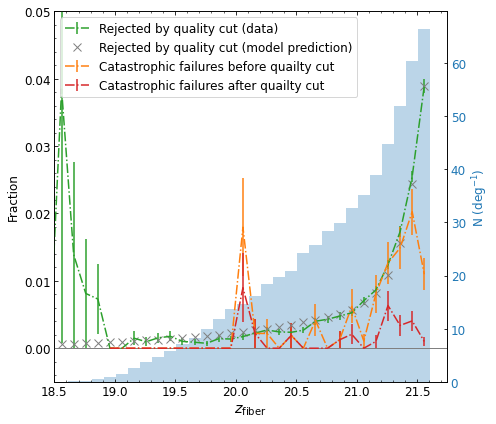

In [24]:
bin_edges = np.linspace(18.01, 22.01, 41)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

mask = cat['main_lrg'].copy()
mask &= mask_nominal
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(cat['zfibermag'][mask], mask_fail[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_still_fail_rate, bin_still_fail_rate_err = binned_frac(cat['zfibermag'][mask], (cat['q'] & mask_fail)[mask], bin_edges, minsize=10, error_floor=False)

mask = mask_nominal_main.copy()
bin_center_main, bin_reject_rate_main, bin_reject_rate_err_main = binned_frac(main['zfibermag'][mask], (~main['q'])[mask], bin_edges, minsize=10, error_floor=False)
_, bin_reject_rate_predict, _ = binned_frac(main['zfibermag'][mask], main['fail_prob'][mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7., 6.))
ax1.plot(bin_center, bin_reject_rate_predict, 'x', color='C7', ms=8,
             label='Rejected by quality cut (model prediction)')
ax1.errorbar(bin_center_main, bin_reject_rate_main,
             yerr=(np.clip(bin_reject_rate_err_main, None, bin_reject_rate_main), bin_reject_rate_err_main),
             fmt='-.', label='Rejected by quality cut (data)', color='C2')
ax1.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='-.', label='Catastrophic failures before quality cut')
ax1.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='-.', label='Catastrophic failures after quality cut')
ax1.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax1.set_ylabel('Fraction')
# ax1.grid(alpha=0.5)
# ax1.title('Main LRGs')
ax1.axis([18.5, 21.75, -0.005, 0.05])
ax2 = ax1.twinx()
ax2_color = 'C0'
area = len(main)/600
ax2.hist(main['zfibermag'], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(len(main), 1/area))
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

handles, labels = ax1.get_legend_handles_labels()
order = [1, 0, 2, 3]
ax1.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='upper left')
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.axhline(0, lw=1, color='0.5')

ax1.set_zorder(1)
ax1.patch.set_visible(False)

plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_vs_zfiber.pdf')
plt.show()

__SV1 LRGs__

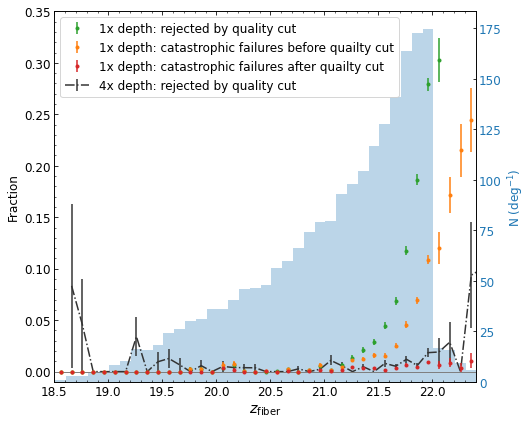

In [25]:
bin_edges = np.linspace(18.01, 23.01, 51)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

mask = mask_nominal.copy()
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['zfibermag'][mask], (~cat['q'])[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(cat['zfibermag'][mask], mask_fail[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_still_fail_rate, bin_still_fail_rate_err = binned_frac(cat['zfibermag'][mask], (cat['q'] & mask_fail)[mask], bin_edges, minsize=10, error_floor=False)

mask_deep = (deep['EFFTIME_LRG']>3200.) & (deep['EFFTIME_LRG']<4800.)
bin_center, bin_reject_rate_deep, bin_reject_rate_err_deep = binned_frac(deep['zfibermag'][mask_deep], (~deep['q'])[mask_deep], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7.5, 6.))
ax1.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='1x depth: rejected by quality cut', color='C2')
ax1.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.', label='1x depth: catastrophic failures before quality cut')
ax1.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='.', label='1x depth: catastrophic failures after quality cut')
ax1.errorbar(bin_center, bin_reject_rate_deep, color='0.2',
             yerr=(np.clip(bin_reject_rate_err_deep, None, bin_reject_rate_deep), bin_reject_rate_err_deep),
             fmt='-.', label='4x depth: rejected by quality cut', zorder=0)
ax1.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax1.set_ylabel('Fraction')
# ax1.grid(alpha=0.5)
# ax1.title('Main LRGs')
ax1.axis([18.5, 22.4, -0.01, 0.35])
ax2 = ax1.twinx()
ax2_color = 'C0'
area = len(cat)/2120
ax2.hist(cat['zfibermag'], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(len(cat), 1/area))
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

handles, labels = ax1.get_legend_handles_labels()
# order = [0, 1, 2, 3]
# ax1.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='upper left')
ax1.legend()
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.axhline(0, lw=1, color='0.5')

ax1.set_zorder(1)
ax1.patch.set_visible(False)

plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/sv1_failure_rate_vs_zfiber.pdf')
plt.show()